# sprint 4. XAI: SHAP explicabilidade dos modelos
 

etapas:
1. SHAP sobre o Modelo 1 (XGBoost):summary plot, beeswarm e waterfall
2. SHAP sobre o Modelo 2 (Random Forest):summary plot, beeswarm e waterfall por cluster
3. Identificar quais variáveis clínicas têm maior peso preditivo
4. Interpretar sob perspectiva clínica


o modelo confunde o c2 com os dois extremos (c1 e c3) -> entender quais features estão causando essa confusão?



## imports

In [1]:
%pip install shap -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
SEED = 42

Note: you may need to restart the kernel to use updated packages.


KeyboardInterrupt: 

## 1. carregar dados e modelos

- **Modelo 1 (XGBoost):** esse bebe vai ter doenca?
- **Modelo 2 (Random Forest):** qual microbiomao bebe tem?

In [ ]:
# modelo 1: XGBoost
with open("../data/processed/xgb_model1.pkl", "rb") as f:
    xgb_m1 = pickle.load(f)

df_m1 = pd.read_csv("../data/processed/model1_encoded.csv")
TARGET_M1 = "adverse_outcomes"
FEAT_M1 = [c for c in df_m1.columns if c not in ("sample_id", TARGET_M1)]
X_m1 = df_m1[FEAT_M1].values
y_m1 = df_m1[TARGET_M1].values

# recriar split idêntico ao sprint 3
X_train_m1, X_test_m1, y_train_m1, y_test_m1 = train_test_split(
    X_m1, y_m1, test_size=0.20, stratify=y_m1, random_state=SEED
)

print(f"modelo 1 (XGBoost) carregado")
print(f"  treino  : {X_train_m1.shape}  ({y_train_m1.sum()} pos, {(y_train_m1==0).sum()} neg)")
print(f"  holdout : {X_test_m1.shape}")
print(f"  features: {FEAT_M1}")

modelo 1 (XGBoost) carregado
  treino  : (166, 12)  (49 pos, 117 neg)
  holdout : (42, 12)
  features: ['birth_mode', 'mother_antibiotics', 'baby_sex', 'baby_ethnicity', 'baby_race', 'Normed Age at Collection (days)', 'amr_gene_sum_abundance', 'vf_sum_abundance', 'antibiotics_first_2_years', 'feeding_Breast', 'feeding_Formula', 'feeding_Mixed']


In [ ]:
# modelo 2: Random Forest (retreinar — nao foi salvo na sprint 2)
df_m2 = pd.read_csv("../data/processed/model2_encoded.csv")
TARGET_M2 = "dmm_clusters_taxa"
FEAT_M2 = [c for c in df_m2.columns if c not in ("sample_id", TARGET_M2)]
X_m2 = df_m2[FEAT_M2].values
y_m2 = df_m2[TARGET_M2].values

rf_m2 = RandomForestClassifier(
    n_estimators=400, max_depth=None, min_samples_leaf=1,
    max_features="sqrt", class_weight="balanced",
    random_state=SEED, n_jobs=-1
)
rf_m2.fit(X_m2, y_m2)
CLASSES_M2 = list(rf_m2.classes_)

print(f"modelo 2 (Random Forest) retreinado")
print(f"  n={X_m2.shape[0]} | features={X_m2.shape[1]} | classes: {CLASSES_M2}")
print(f"  features: {FEAT_M2}")

modelo 2 (Random Forest) retreinado
  n=412 | features=11 | classes: ['C1', 'C2', 'C3']
  features: ['birth_mode', 'mother_antibiotics', 'baby_sex', 'baby_ethnicity', 'baby_race', 'Normed Age at Collection (days)', 'amr_gene_sum_abundance', 'vf_sum_abundance', 'feeding_Breast', 'feeding_Formula', 'feeding_Mixed']


## 2. SHAP: Modelo 1 (XGBoost, desfecho adverso binário)

 calcula SHAP values exatos para modelos baseados em árvores
 
  
Cada SHAP value = contribuição de uma feature para empurrar a predição acima (positivo) ou abaixo (negativo) do valor base

### 2.1 TreeExplainer + SHAP values

In [ ]:
explainer_m1 = shap.TreeExplainer(xgb_m1)
sv_m1 = explainer_m1.shap_values(X_train_m1)

print(f"SHAP values — modelo 1")
print(f"  shape      : {sv_m1.shape}  (n_treino x n_features)")
print(f"  valor base : {explainer_m1.expected_value:.4f}  (predicao media em log-odds)")
print()
importances_m1 = pd.Series(np.abs(sv_m1).mean(axis=0), index=FEAT_M1).sort_values(ascending=False)
print("ranking mean |SHAP|:")
for rank, (feat, val) in enumerate(importances_m1.items(), 1):
    print(f"  {rank:>2}. {feat:<45} {val:.4f}")

SHAP values — modelo 1
  shape      : (166, 12)  (n_treino x n_features)
  valor base : -0.0089  (predicao media em log-odds)

ranking mean |SHAP|:
   1. amr_gene_sum_abundance                        1.0575
   2. vf_sum_abundance                              0.8737
   3. Normed Age at Collection (days)               0.4642
   4. antibiotics_first_2_years                     0.4507
   5. feeding_Breast                                0.1063
   6. baby_sex                                      0.0774
   7. baby_race                                     0.0583
   8. birth_mode                                    0.0500
   9. baby_ethnicity                                0.0255
  10. feeding_Mixed                                 0.0211
  11. feeding_Formula                               0.0146
  12. mother_antibiotics                            0.0000


### 2.2 importância global: bar chart e beeswarm

- **Bar chart:** ranking por mean |SHAP| -> magnitude média, sem direção
- **Beeswarm:** cada ponto é uma amostra

 Cor = valor da feature (vermelho alto, azul baixo)
 
  Posição x = impacto na predição

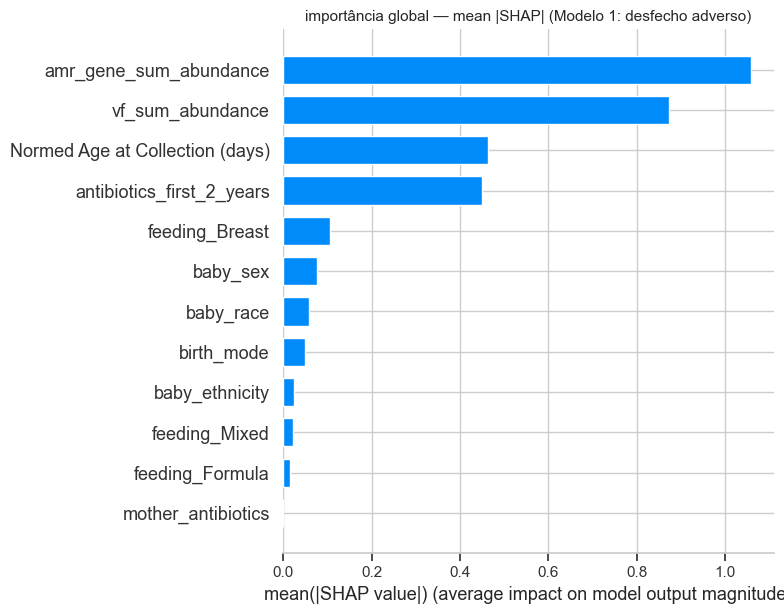

In [ ]:
plt.figure(figsize=(8, 5))
shap.summary_plot(sv_m1, X_train_m1, feature_names=FEAT_M1,
                  plot_type="bar", show=False, max_display=12)
plt.title("importância global — mean |SHAP| (Modelo 1: desfecho adverso)", fontsize=11)
plt.tight_layout()
plt.show()

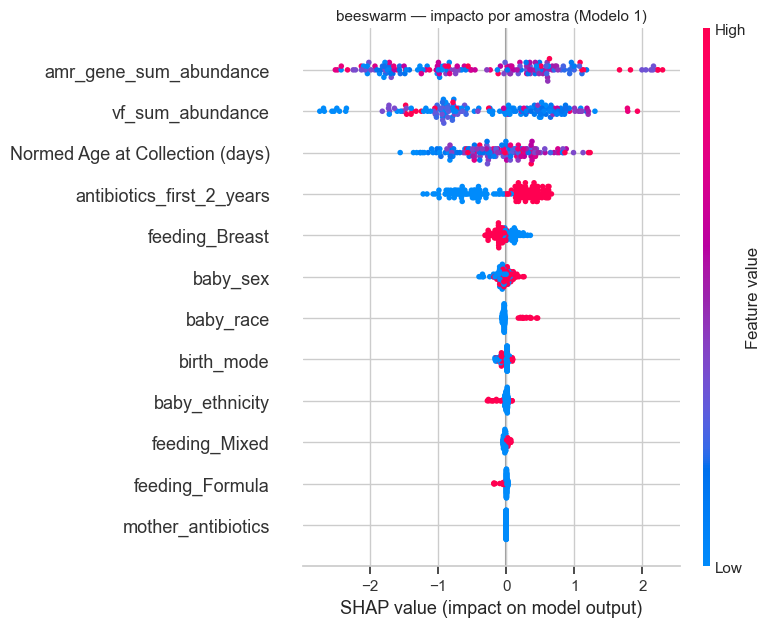

In [ ]:
plt.figure(figsize=(9, 6))
shap.summary_plot(sv_m1, X_train_m1, feature_names=FEAT_M1,
                  show=False, max_display=12)
plt.title("beeswarm — impacto por amostra (Modelo 1)", fontsize=11)
plt.show()

pegar a quantidade de amostra -> e colocar no grafico de barras para mostrar que a feature é importante não só por ter um SHAP alto, mas também por ser relevante para muitas amostras

### 2.3 waterfall: exemplos individuais

mostra como cada feature empurrou a predição do valor base até o valor final para uma amostra específica


positivo mais confiante (maior prob predita entre os reais positivos) e o negativo mais confiante

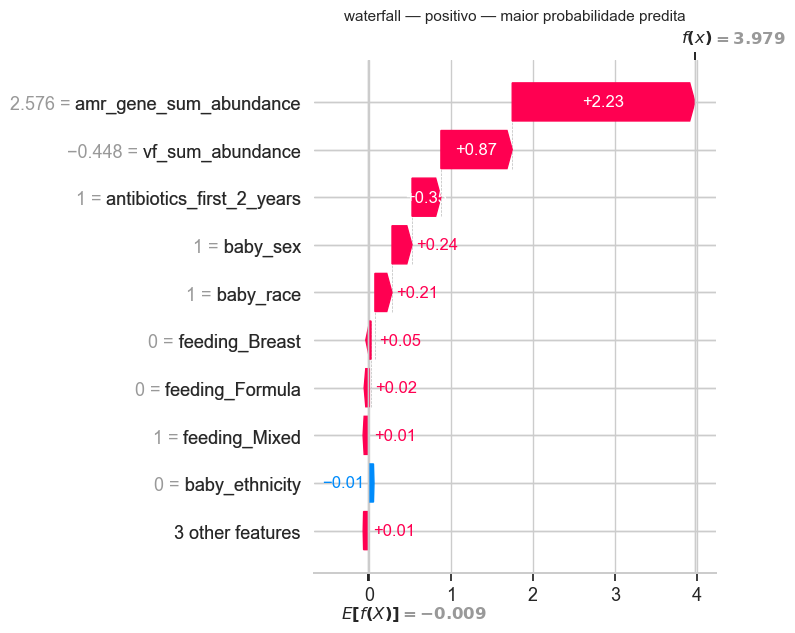

  prob predita: 0.9816 | classe real: 1



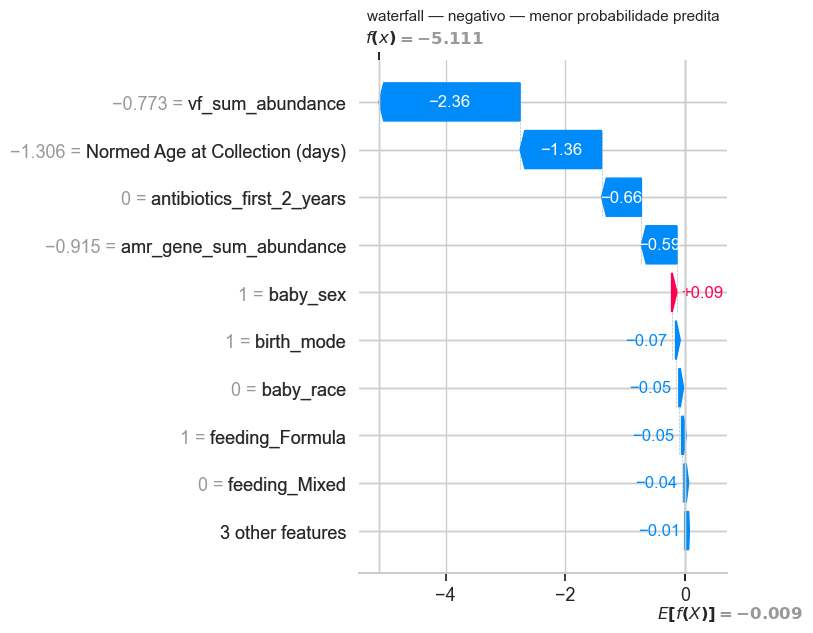

  prob predita: 0.0060 | classe real: 0



In [ ]:
y_prob_train_m1 = xgb_m1.predict_proba(X_train_m1)[:, 1]

pos_idx = np.where(y_train_m1 == 1)[0]
neg_idx = np.where(y_train_m1 == 0)[0]
idx_pos = pos_idx[np.argmax(y_prob_train_m1[pos_idx])]
idx_neg = neg_idx[np.argmin(y_prob_train_m1[neg_idx])]

for idx, label in [
    (idx_pos, "positivo — maior probabilidade predita"),
    (idx_neg, "negativo — menor probabilidade predita")
]:
    sv_single = shap.Explanation(
        values=sv_m1[idx],
        base_values=explainer_m1.expected_value,
        data=X_train_m1[idx],
        feature_names=FEAT_M1
    )
    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(sv_single, show=False)
    plt.title(f"waterfall — {label}", fontsize=11)
    plt.tight_layout()
    plt.show()
    print(f"  prob predita: {y_prob_train_m1[idx]:.4f} | classe real: {y_train_m1[idx]}")
    print()

## 3. SHAP : Modelo 2 (Random Forest, cluster DMM)

oara multiclasse o SHAP gera um conjunto de valores por classe -> cada valor indica quanto cada feature contribui para aumentar ou reduzir a probabilidade daquele cluster.

### 3.1 TreeExplainer + SHAP values

In [ ]:
explainer_m2 = shap.TreeExplainer(rf_m2)
sv_m2_raw = explainer_m2.shap_values(X_m2)

# newer SHAP returns a 3-D array (n_samples, n_features, n_classes);
# older SHAP returns a list of (n_samples, n_features) arrays per class
if isinstance(sv_m2_raw, np.ndarray) and sv_m2_raw.ndim == 3:
    sv_m2_list = [sv_m2_raw[:, :, i] for i in range(sv_m2_raw.shape[2])]
else:
    sv_m2_list = sv_m2_raw

print("SHAP values — modelo 2")
for i, cls in enumerate(CLASSES_M2):
    print(f"  {cls}: shape {sv_m2_list[i].shape} | base={explainer_m2.expected_value[i]:.4f}")

print()
imp_m2 = pd.DataFrame(
    {cls: np.abs(sv_m2_list[i]).mean(axis=0) for i, cls in enumerate(CLASSES_M2)},
    index=FEAT_M2
).sort_values("C1", ascending=False)
print("mean |SHAP| por feature e cluster:")
print(imp_m2.round(4).to_string())

SHAP values — modelo 2
  C1: shape (412, 11) | base=0.3336
  C2: shape (412, 11) | base=0.3334
  C3: shape (412, 11) | base=0.3329

mean |SHAP| por feature e cluster:
                                     C1      C2      C3
amr_gene_sum_abundance           0.1123  0.0782  0.1277
vf_sum_abundance                 0.0761  0.0849  0.1186
Normed Age at Collection (days)  0.0444  0.0428  0.0440
feeding_Breast                   0.0386  0.0332  0.0258
birth_mode                       0.0194  0.0415  0.0502
baby_sex                         0.0174  0.0209  0.0192
feeding_Mixed                    0.0171  0.0189  0.0152
baby_ethnicity                   0.0092  0.0156  0.0137
feeding_Formula                  0.0088  0.0086  0.0085
baby_race                        0.0066  0.0056  0.0054
mother_antibiotics               0.0015  0.0018  0.0015


### 3.2 importância global por classe: bar chart

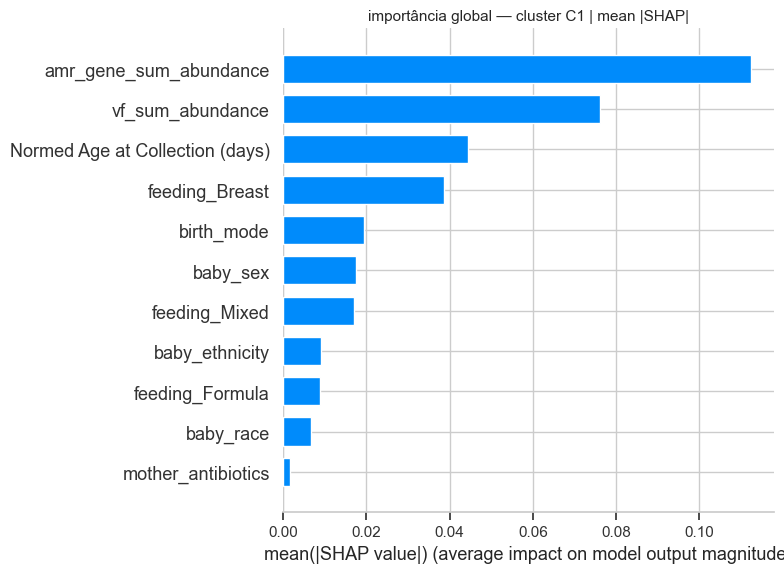

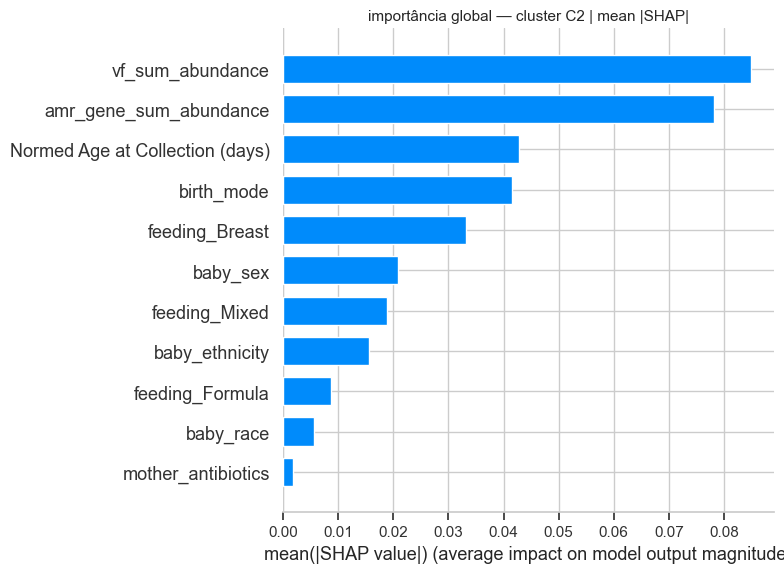

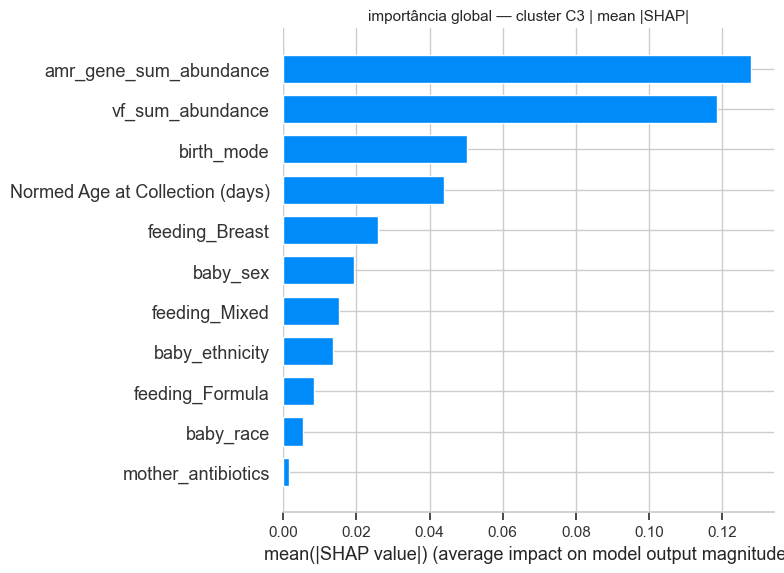

In [ ]:
for i, cls in enumerate(CLASSES_M2):
    plt.figure(figsize=(7, 5))
    shap.summary_plot(sv_m2_list[i], X_m2, feature_names=FEAT_M2,
                      plot_type="bar", show=False, max_display=11)
    plt.title(f"importância global — cluster {cls} | mean |SHAP|", fontsize=11)
    plt.tight_layout()
    plt.show()

### 3.3 beeswarm por classe

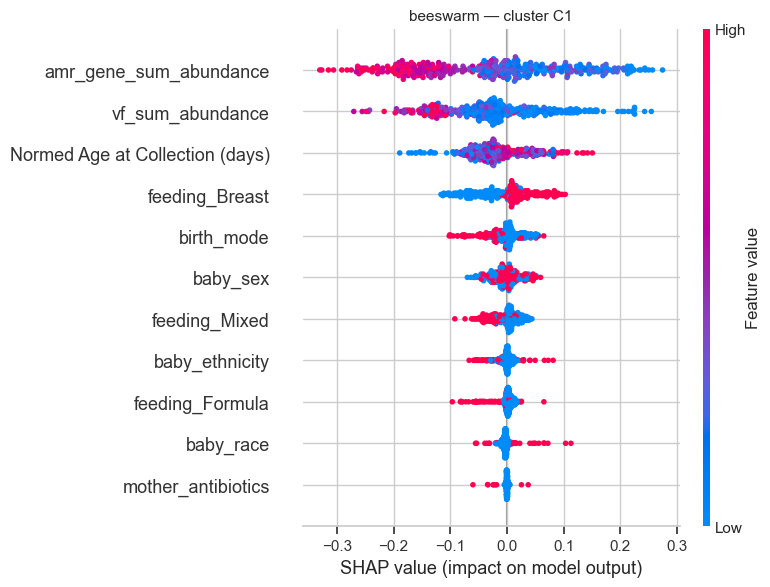

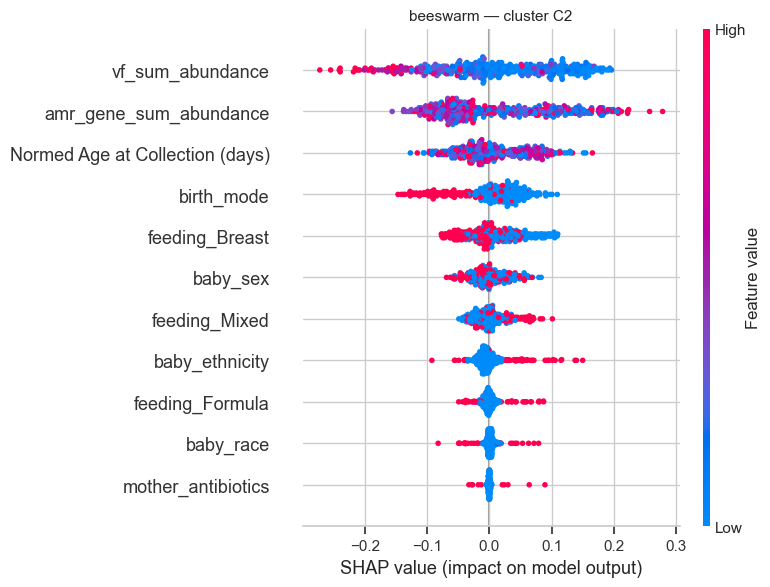

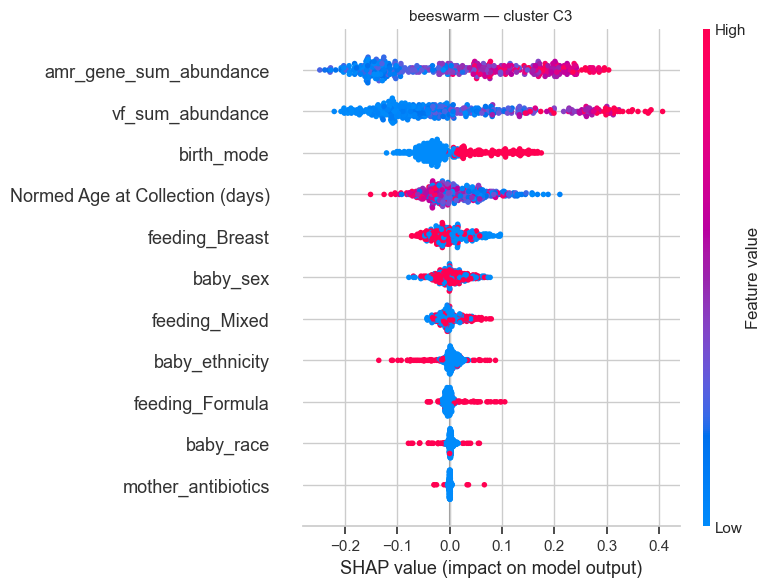

In [ ]:
for i, cls in enumerate(CLASSES_M2):
    plt.figure(figsize=(9, 6))
    shap.summary_plot(sv_m2_list[i], X_m2, feature_names=FEAT_M2,
                      show=False, max_display=11)
    plt.title(f"beeswarm — cluster {cls}", fontsize=11)
    plt.show()

c2????


tirar o c2 pra treinar o modelo

### 3.4 waterfall: amostra mais representativa por cluster

p cada cluster, seleciona a amostra com maior probabilidade predita naquela class

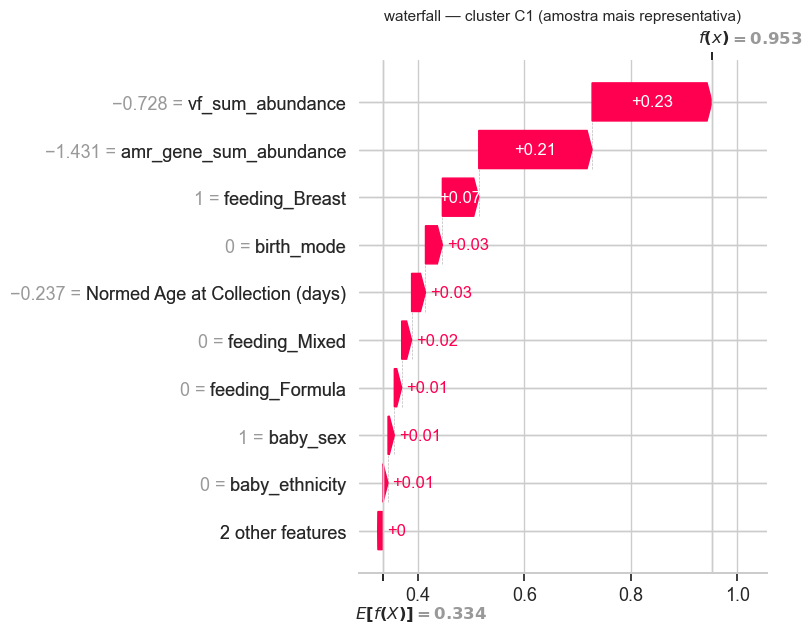

  prob predita (C1): 0.9525 | cluster real: C1



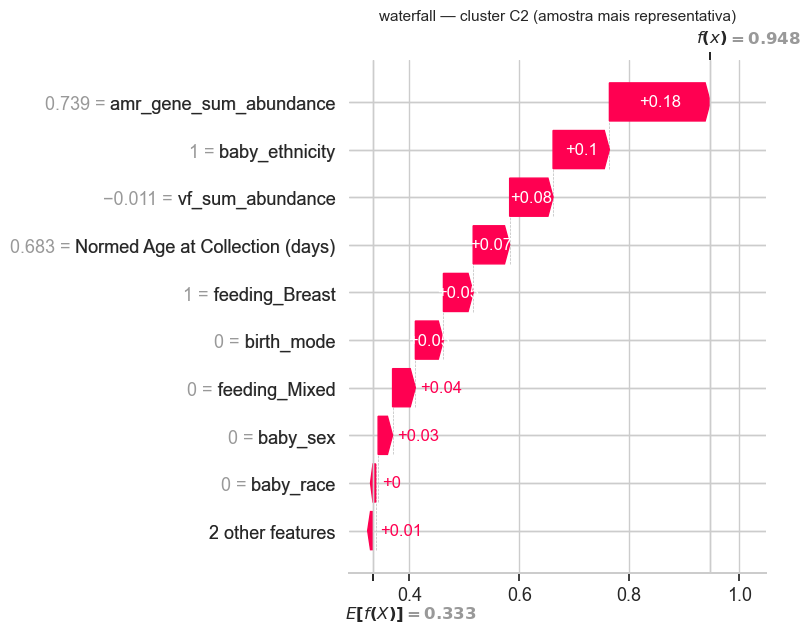

  prob predita (C2): 0.9475 | cluster real: C2



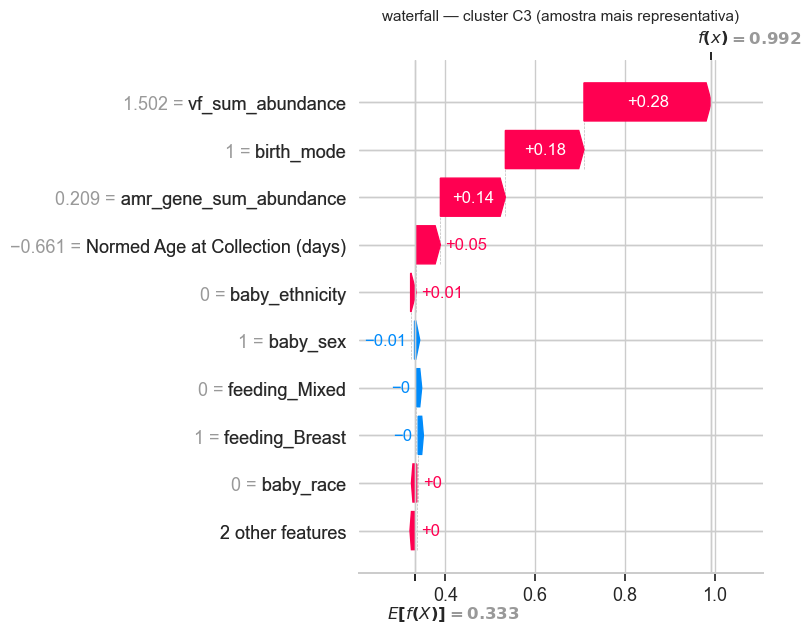

  prob predita (C3): 0.9925 | cluster real: C3



In [ ]:
rf_probs_all = rf_m2.predict_proba(X_m2)

for i, cls in enumerate(CLASSES_M2):
    cls_mask = (y_m2 == cls)
    idx = np.where(cls_mask)[0][np.argmax(rf_probs_all[cls_mask, i])]

    sv_single = shap.Explanation(
        values=sv_m2_list[i][idx],
        base_values=explainer_m2.expected_value[i],
        data=X_m2[idx],
        feature_names=FEAT_M2
    )
    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(sv_single, show=False)
    plt.title(f"waterfall — cluster {cls} (amostra mais representativa)", fontsize=11)
    plt.tight_layout()
    plt.show()
    print(f"  prob predita ({cls}): {rf_probs_all[idx, i]:.4f} | cluster real: {y_m2[idx]}")
    print()

o que acontece com o modelo se tirar as features mais importantes? o modelo piora? quais features são mais críticas para a predição?

usar varios modelos, com diferentes combinações de features, para ver como o desempenho muda (recall, AUC) -> entender a importância relativa das features e se o modelo é robusto a mudanças nas features

linear -> temos poucas features


ver se eu tirar as variaveis vf e amr gene como muda o recall, AUC


-> seria bom fazer um modelo só para diferenciar c2 dos outros dois clusters, e ver quais features são mais importantes para essa distinção específica



-> seria ter mais features:
- estado de nascimento
- data de nascimento

e das features de estado e data de nascimento, extrair:
- estação do ano
- mês do nascimento
- idade da mãe no parto (tem como?)


nao sei se tem essas features, mas se tiver, seria interessante ver o impacto delas:
- peso ao nascer 
- idade gestacional
- tipo de parto
- uso de antibióticos
- amamentação    


acho que a eda esta bem ruim, nao ta avaliando as coisas bem tipo a criacao de features

-> usar todos os modelos disponiveis? tipo dos mais basicos como linear regression, logistic regression, até os mais complexos como xgboost e random forest, para ver como a importância das features muda entre os modelos e se tem alguma feature que é consistentemente importante em todos os modelos.

-> usar diferentes combinacoes
 de hiperparametros pra ver qual é a configuração mais robusta e se a importância das features muda com diferentes hiperparametros (depois colocar todos os modelos, hiperparametros, resultados dos modelos e as metricas em um json pra facilidar a comparacao e ver o shap xai)


-> o que eh o cluster h1,h2..?

suplementary data 5: eh oq? as coisas dao pra pegar em exame de fezes comuns

-> oq eh esse dmm cluster taxa paper? adverse outcomes, 

## 4. interpretação clínica

### 4.1 o que os SHAP values revelam sobre o Modelo 1 (desfecho adverso)

**`amr_gene_sum_abundance` e `vf_sum_abundance` dominam as predições (mean|SHAP| = 1.06 e 0.87).**  
Isso faz sentido biológico: abundância elevada de genes de resistência antimicrobiana (AMR) e de fatores de virulência (VF) indica um microbioma colonizado por bactérias patogênicas ou oportunistas. Esse perfil de "microbioma de risco" está associado a ativação inflamatória crônica de baixo grau — mecanismo central para o desenvolvimento de doenças atópicas (alergia, asma, eczema). O modelo, sem nunca ter visto as sequências bacterianas diretamente, aprendeu que a *soma* da carga de risco do microbioma é o principal sinal preditivo.

**`Normed Age at Collection (days)` em terceiro lugar (0.46).**  
O microbioma infantil muda rapidamente nos primeiros meses de vida. A idade na coleta determina em qual janela do desenvolvimento microbiano a amostra foi capturada — coletas mais tardias refletem um microbioma mais estabilizado, enquanto coletas muito precoces capturam a fase de colonização inicial, que é biologicamente mais instável. O modelo usa essa informação para calibrar o peso dos outros sinais.

**`antibiotics_first_2_years` em quarto lugar (0.45).**  
Apesar de sua importância, é preciso cautela na interpretação: essa variável é coletada no follow-up (não disponível ao nascimento) e pode ser um **mediador** — ou seja, um microbioma mais patogênico aumenta o risco de infecções, que levam ao uso de antibióticos, que por sua vez agrava o microbioma. Incluir um mediador no modelo infla artificialmente o desempenho sem adicionar valor causal. Por isso o `xgb_birth_only` (sem essa covariate) é o modelo clinicamente mais honesto para triagem neonatal.

**`feeding_Breast` em quinto lugar (0.11).**  
O aleitamento materno exclusivo é o principal intervenível: promove a colonização por *Bifidobacterium* e inibe bactérias pró-inflamatórias. O modelo capturou corretamente que a ausência de aleitamento (feeding_Formula ou feeding_Mixed) aumenta o risco — consistente com décadas de literatura pediátrica.

**`mother_antibiotics` com importância zero.**  
Surpreendente. Uma hipótese: o sinal de antibióticos maternos já está capturado indiretamente pela abundância de AMR (mães que usaram antibióticos transferem bactérias resistentes ao bebê, elevando o amr_gene_sum_abundance). A colinearidade entre essas variáveis pode ter feito o modelo atribuir o crédito todo ao AMR, zerando o impacto direto da variável clínica original.

---

### 4.2 o que os SHAP values revelam sobre o Modelo 2 (cluster DMM)

**AMR e VF também lideram para os três clusters**, mas com perfis distintos:

| feature | C1 (saudável) | C2 (intermediário) | C3 (alto risco) |
|---|---|---|---|
| `amr_gene_sum_abundance` | 0.1123 | 0.0782 | **0.1277** |
| `vf_sum_abundance` | 0.0761 | 0.0849 | **0.1186** |
| `feeding_Breast` | **0.0386** | 0.0332 | 0.0258 |
| `birth_mode` | 0.0194 | 0.0415 | **0.0502** |

- **Para C3:** AMR e VF têm os maiores SHAP values — o modelo identifica C3 principalmente pelo perfil de carga patogênica elevada. Faz sentido: C3 é o cluster de alto risco com mais bactérias de Firmicutes e Proteobacteria.
- **Para C1:** `feeding_Breast` tem peso relativo maior. O microbioma saudável é caracterizado por dominância de *Bifidobacterium*, e o aleitamento materno é o principal driver desse perfil.
- **Para C2:** os SHAP values são os mais baixos e distribuídos entre features. Isso explica a confusão do modelo com C2 — não existe uma combinação clara de features clínicas que o identifique de forma limpa. C2 é um cluster biologicamente intermediário, e sua definição depende de composição bacteriana granular que as features clínicas não conseguem capturar completamente.

---

### 4.3 o modelo aprendeu algo biologicamente plausível?

**Sim.** O que o modelo capturou está alinhado com o que a literatura de microbioma infantil estabelece:

1. A carga de patógenos (AMR + VF) é um proxy da disbiose microbiana — o maior fator de risco identificado
2. Aleitamento materno protege via modulação do microbioma (C1)
3. Parto cesáreo aumenta risco (C3) ao privar o bebê da colonização vaginal
4. A idade na coleta é um confundidor importante que o modelo corretamente incorpora

**Nenhuma feature inverossímil entrou no ranking dominante.** O modelo não encontrou, por exemplo, `baby_race` ou `baby_ethnicity` como top features — variáveis que seriam sinais espúrios sem mecanismo causal.

---

### 4.4 limitações e o que isso significa para uso clínico

- **C2 é clinicamente inacessível com features de nascimento.** O modelo não consegue identificar C2 com precisão porque esse cluster é definido por composição bacteriana que só existe após a colonização — não há sinal clínico pré-natal suficiente.
- **n=210 é pequeno para o Modelo 1.** Com ~60 positivos, o modelo é sensível a variações de amostragem. Os SHAP values individuais (waterfall) devem ser interpretados com cautela.
- **AMR e VF são coletados por sequenciamento fecal** — não disponíveis em consultas de rotina. Para triagem neonatal real, o modelo com apenas as features clínicas (sem AMR/VF) seria o cenário operacional. Esse modelo existe (`xgb_birth_only`), mas com desempenho inferior — o que quantifica o valor do sequenciamento metagenômico.

---

### 4.5 implicações translacionais

O principal achado translacional é que **dois exames acessíveis definem quase toda a capacidade preditiva dos modelos**: a abundância de genes AMR e a carga de fatores de virulência — ambos obtidos por sequenciamento de fezes.

Para uma intervenção prática: bebês com `amr_gene_sum_abundance` e `vf_sum_abundance` elevados nos primeiros meses de vida, especialmente nascidos por cesariana e sem aleitamento materno exclusivo, compõem o grupo de maior risco e poderiam ser priorizados para acompanhamento pediátrico antecipado de doenças atópicas.